# PART A: DATA PREPARATION
Step 1: LoadING DATA AND BASIC INFO

In [5]:
import pandas as pd
trades=pd.read_csv(r"E:\datascience-assignment\DATA\historical_data.csv")
sentiment=pd.read_csv(r"E:\datascience-assignment\DATA\fear_greed_index.csv")


In [6]:
print(trades)

                                           Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   

        Size Tokens  Size U

In [7]:
print(sentiment)

       timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]


In [8]:
print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [9]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


Step 2: Missing Values and Duplicates

In [10]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [12]:
print("Duplicates(trades):",trades.duplicated().sum())

Duplicates(trades): 0


In [13]:
print("Duplicates(Sentiment):",sentiment.duplicated().sum())

Duplicates(Sentiment): 0


Step 3: Convert Time & Align Dates

In [14]:
trades['Date']=pd.to_datetime(trades['Timestamp'],unit='ms').dt.date

In [15]:
print(trades['Date'])

0         2024-10-27
1         2024-10-27
2         2024-10-27
3         2024-10-27
4         2024-10-27
             ...    
211219    2025-06-15
211220    2025-06-15
211221    2025-06-15
211222    2025-06-15
211223    2025-06-15
Name: Date, Length: 211224, dtype: object


In [16]:
sentiment['Date']=pd.to_datetime(sentiment['date']).dt.date

In [17]:
print(sentiment['Date'])

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: Date, Length: 2644, dtype: object


In [18]:
# Keep relevant columns
sentiment=sentiment[['Date','classification']]

In [19]:
print(sentiment)

            Date classification
0     2018-02-01           Fear
1     2018-02-02   Extreme Fear
2     2018-02-03           Fear
3     2018-02-04   Extreme Fear
4     2018-02-05   Extreme Fear
...          ...            ...
2639  2025-04-28        Neutral
2640  2025-04-29          Greed
2641  2025-04-30          Greed
2642  2025-05-01        Neutral
2643  2025-05-02          Greed

[2644 rows x 2 columns]


Step 4: Creating Key Metrics

In [20]:
# 1 Daily PnL per trade
trades.rename(columns={'Closed PnL': 'PnL'},inplace=True)
daily_pnl=trades.groupby(['Account','Date'])['PnL'].sum().reset_index()

In [21]:
print(trades['PnL'])

0           0.0000
1           0.0000
2           0.0000
3           0.0000
4           0.0000
            ...   
211219    -20.2566
211220   -112.5773
211221    -22.4402
211222   -190.7894
211223    -53.9063
Name: PnL, Length: 211224, dtype: float64


In [22]:
trades[['Account','Date']].drop_duplicates().shape

(102, 2)

In [23]:
# Number of trades per day
trades_per_day=trades.groupby(['Account','Date']).size().reset_index(name='num_trades')

In [24]:
print(trades_per_day)

                                        Account        Date  num_trades
0    0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27         462
1    0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19        3356
2    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27         320
3    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19        3533
4    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15        3427
..                                          ...         ...         ...
97   0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2025-02-19        2211
98   0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2025-06-15         163
99   0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2024-10-27        9883
100  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-02-19       26651
101  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-06-15        3650

[102 rows x 3 columns]


In [25]:
# Average trade size
avg_size=trades.groupby(['Account','Date'])['Execution Price'].mean().reset_index(name='avg_size')

In [26]:
print(avg_size)

                                        Account        Date      avg_size
0    0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27   2651.017619
1    0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19   1985.464055
2    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27    376.192394
3    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19    168.790344
4    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15    355.124852
..                                          ...         ...           ...
97   0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2025-02-19  23836.939773
98   0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2025-06-15   1286.381421
99   0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2024-10-27     81.219358
100  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-02-19     24.946384
101  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-06-15     18.378641

[102 rows x 3 columns]


In [27]:
# Win Rate
trades['win']=trades['PnL'].apply(lambda x:1 if x>0 else 0)
win_rate=trades.groupby(['Account','Date'])['win'].mean().reset_index(name='win_rate')

In [28]:
print(win_rate)

                                        Account        Date  win_rate
0    0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27  0.025974
1    0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  0.405542
2    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  0.531250
3    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  0.435041
4    0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-06-15  0.442369
..                                          ...         ...       ...
97   0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2025-02-19  0.372230
98   0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3  2025-06-15  0.006135
99   0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2024-10-27  0.569260
100  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-02-19  0.384864
101  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  2025-06-15  0.363014

[102 rows x 3 columns]


In [29]:
# Leverage Distribution
# Avoid division by zero
trades = trades[trades['Size USD'] != 0].copy()

# Create implied leverage proxy
trades['implied_leverage'] = abs(trades['PnL']) / trades['Size USD']

In [30]:
def categorize_lev(x):
    if x > 0.05:
        return 'High'
    elif x > 0.02:
        return 'Medium'
    else:
        return 'Low'

trades['leverage_cat'] = trades['implied_leverage'].apply(categorize_lev)

In [31]:
print(trades['leverage_cat'])

0            Low
1            Low
2            Low
3            Low
4            Low
           ...  
211219    Medium
211220    Medium
211221    Medium
211222    Medium
211223    Medium
Name: leverage_cat, Length: 211181, dtype: object


In [32]:
trades['leverage_cat'].value_counts()

leverage_cat
Low       160956
High       27162
Medium     23063
Name: count, dtype: int64

In [33]:
# Long/Short Ratio
long_short=trades.groupby(['Date','Side']).size().unstack(fill_value=0)
long_short['long_short_ratio']=long_short['BUY']/(long_short['SELL']+1)
long_short=long_short.reset_index()

In [34]:
print(long_short[['long_short_ratio']])  
# ratio >1 more LONG trades(bullish behaviour)
# ratio <1 more SHORT trades(Bearish behaviour)
# ratio=1 balanced

Side  long_short_ratio
0             3.000000
1             0.884685
2             0.938474
3             0.968767
4             0.735212
5             0.974948
6             1.132395


In [35]:
# Merge Everything
daily_pnl = trades.groupby(['Account','Date'])['PnL'].sum().reset_index()

df = daily_pnl.merge(trades_per_day, on=['Account','Date'])
df = df.merge(win_rate, on=['Account','Date'])
df = df.merge(avg_size, on=['Account','Date'])
df = df.merge(sentiment, on='Date', how='left')

In [36]:
df

,Account,Date,PnL,num_trades,win_rate,avg_size,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,0.025974,2651.017619,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,0.405542,1985.464055,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,0.531250,376.192394,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,0.435041,168.790344,Fear
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04,3427,0.442369,355.124852,NaN
...,...,...,...,...,...,...,...
97,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-02-19,3.254420e+05,2211,0.372230,23836.939773,Fear
98,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-06-15,-1.165946e+05,163,0.006135,1286.381421,NaN
99,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2024-10-27,6.842150e+05,9883,0.569260,81.219358,Greed
100,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-02-19,1.269680e+05,26651,0.384864,24.946384,Fear


In [37]:
print("Total rows:", len(df))
print("Missing classification:", df['classification'].isnull().sum())

Total rows: 102
Missing classification: 25


In [38]:
print(df['Date'].head())
print(sentiment['Date'].head())

0    2024-10-27
1    2025-02-19
2    2024-10-27
3    2025-02-19
4    2025-06-15
Name: Date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


In [39]:
df['Date'] = pd.to_datetime(df['Date']).dt.date
sentiment['Date'] = pd.to_datetime(sentiment['Date']).dt.date

In [40]:
df = df.drop(columns=['classification'], errors='ignore')

df = df.merge(sentiment, on='Date', how='left')

In [41]:
 print(df['classification'].isnull().sum())

25


In [42]:
trade_dates = set(df['Date'])
sentiment_dates = set(sentiment['Date'])

missing_dates = trade_dates - sentiment_dates
print("Dates in trades but not in sentiment:", len(missing_dates))
print(list(missing_dates)[:10])

Dates in trades but not in sentiment: 1
[datetime.date(2025, 6, 15)]


In [43]:
df = df[df['Date'] != pd.to_datetime('2025-06-15').date()]

In [44]:
df['classification'].isnull().sum()

0

In [45]:
# missing_dates = df[df['classification'].isnull()]['Date'].unique()
# print(missing_dates[:10])

In [46]:
print(sentiment.columns)

Index(['Date', 'classification'], dtype='object')


# PART B ---> ANALYSIS(CORE)

 1.Performance vs Sentiment

In [47]:
df.groupby('classification')[['PnL','win_rate']].mean()

,PnL,win_rate
classification,,
Extreme Greed,35393.098355,0.336609
Fear,209372.662205,0.415878
Greed,99675.516731,0.374074
Neutral,19842.797260,0.260683


In [48]:
df['cum_pnl'] = df.groupby('Account')['PnL'].cumsum()
df['rolling_max'] = df.groupby('Account')['cum_pnl'].cummax()
df['drawdown'] = df['cum_pnl'] - df['rolling_max']
df

,Account,Date,PnL,num_trades,win_rate,avg_size,classification,cum_pnl,rolling_max,drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,0.025974,2651.017619,Greed,-3.275059e+05,-3.275059e+05,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,0.405542,1985.464055,Fear,1.600230e+06,1.600230e+06,0.0
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,0.531250,376.192394,Greed,2.060745e+04,2.060745e+04,0.0
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,0.435041,168.790344,Fear,3.770617e+04,3.770617e+04,0.0
5,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,5,0.000000,151.754000,Neutral,-1.000000e+00,-1.000000e+00,0.0
...,...,...,...,...,...,...,...,...,...,...
94,0xbaaaf6571ab7d571043ff1e313a9609a10637864,2025-02-19,9.401572e+05,21190,0.467532,20.282435,Fear,9.401572e+05,9.401572e+05,0.0
96,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2024-10-27,1.167168e+04,267,0.153558,7568.242062,Greed,1.167168e+04,1.167168e+04,0.0
97,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-02-19,3.254420e+05,2211,0.372230,23836.939773,Fear,3.371137e+05,3.371137e+05,0.0
99,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2024-10-27,6.842150e+05,9883,0.569260,81.219358,Greed,6.842150e+05,6.842150e+05,0.0


In [49]:
df.shape

(77, 10)

2.Behaviour change

In [50]:
# Trade Frequency
# df.groupby('classification')['num_trades'].count()
df.groupby('classification')['num_trades'].mean()

classification
Extreme Greed    1392.40000
Fear             4183.46875
Greed            1134.03125
Neutral           892.62500
Name: num_trades, dtype: float64

In [51]:
df.groupby('classification')['drawdown'].mean()

classification
Extreme Greed   -1112.803228
Fear            -2496.129364
Greed               0.000000
Neutral         -3917.470960
Name: drawdown, dtype: float64

In [52]:
# Average Trade Size
df.groupby('classification')['avg_size'].mean()

classification
Extreme Greed     5727.717552
Fear             16168.899711
Greed             7788.681805
Neutral           1383.126601
Name: avg_size, dtype: float64

In [53]:
# Leverage Behaviour
# lev_analysis=trades.groupby(['leverage_cat'])['PnL'].count()
lev_analysis=trades.groupby(['leverage_cat'])['PnL'].mean()
print(lev_analysis)

leverage_cat
High      280.350284
Low         9.323315
Medium     51.226687
Name: PnL, dtype: float64


In [54]:
# Long/short Bias
long_short=long_short.merge(sentiment,on='Date')
long_short.groupby('classification')['long_short_ratio'].mean()

classification
Extreme Greed    0.938474
Fear             0.974948
Greed            1.539965
Neutral          0.968767
Name: long_short_ratio, dtype: float64

# Trade Segmentation


In [55]:
# Segment 1:High vs Low Leverage
trades.groupby('leverage_cat')['PnL'].mean()

leverage_cat
High      280.350284
Low         9.323315
Medium     51.226687
Name: PnL, dtype: float64

In [56]:
# Segment 2: Frequent vs Infrequent Traders
df['trader_type']=df['num_trades'].apply(lambda x: 'Frequent' if x>5 else 'Infrequent')

In [57]:
df.groupby('trader_type')['PnL'].mean()

trader_type
Frequent      140047.362131
Infrequent       448.040054
Name: PnL, dtype: float64

# VISUALIZATIONS

PnL vs Sentiment

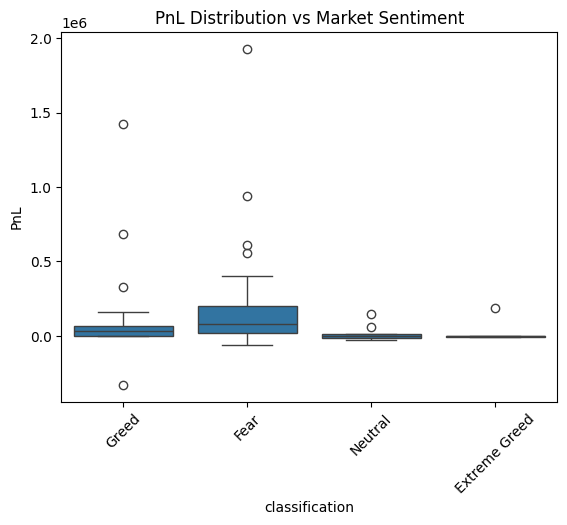

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.boxplot(x='classification', y='PnL', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution vs Market Sentiment")
plt.show()

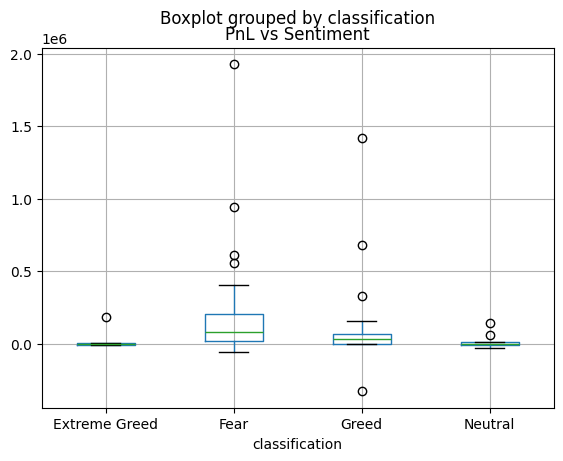

In [59]:
import matplotlib.pyplot as plt
df.boxplot(column='PnL',by='classification')
plt.title('PnL vs Sentiment')
plt.show()

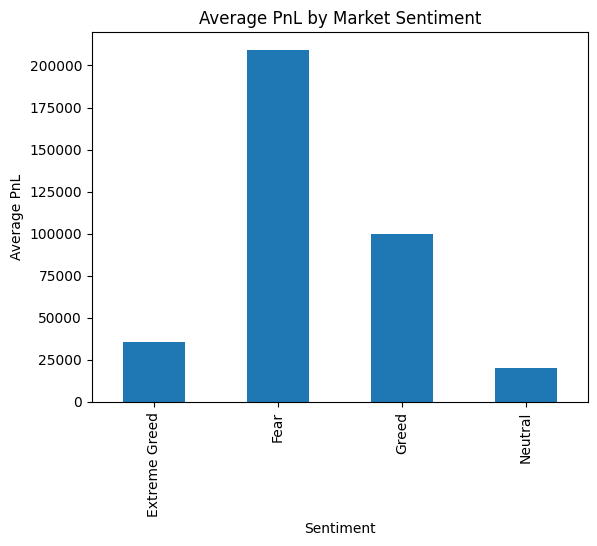

In [60]:
df.groupby('classification')['PnL'].mean().plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

# KEY INSIGHT:
The bar chart shows which market conditions give more profit, and the boxplot shows how stable or risky those profits are.
Together, they tell us that when profits are higher, they usually come with more risk and ups and downs. So, traders should be careful and adjust their strategy based on market conditions.

Trade Frequency

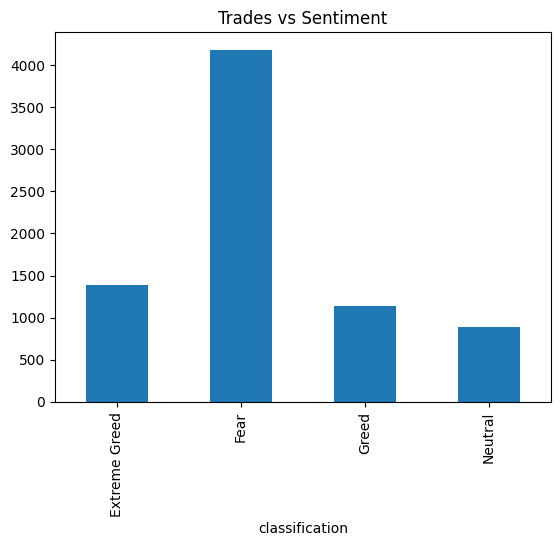

In [61]:
df.groupby('classification')['num_trades'].mean().plot(kind='bar')
plt.title("Trades vs Sentiment")
plt.show()

# Key Insight:
When the market is in Fear, traders make more trades because they react quickly instead of planning carefully. This can lead to mistakes and less consistent results.

Leverage Impact

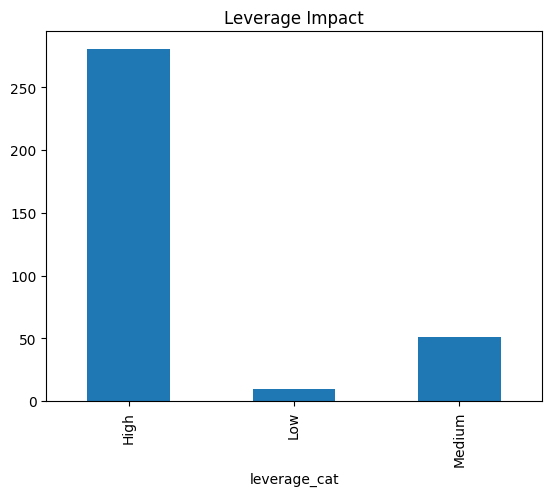

In [62]:
trades.groupby('leverage_cat')['PnL'].mean().plot(kind='bar')
plt.title("Leverage Impact")
plt.show()

# Key Insight:
Using high leverage can help you earn bigger profits, but it can also cause bigger losses. So, it’s important to be careful and manage risk properly.

# Insight 1: High Profit Comes with High Risk
The bar chart shows that Fear periods have the highest average PnL. However, the boxplot and drawdown analysis reveal higher variability and larger losses during these periods. This indicates a high-risk, high-reward environment.
# Insight 2: Fear Leads to Overtrading
The trade frequency chart shows significantly higher trading activity during Fear. This suggests that traders become more reactive and less strategic, which can reduce consistency and efficiency.
# Insight 3: Leverage Amplifies Outcomes
 * The leverage impact chart shows that higher leverage leads to higher average PnL. However, it also increases risk and drawdowns, highlighting the importance of controlled leverage usage.
  * Overall, trader performance is influenced not only by market sentiment but also by behavioral factors such as overtrading, leverage usage, and consistency, highlighting the importance of disciplined and adaptive trading strategies.

# Part C — “Actionable output”
* 2 strategy ideas or “rules of thumb” based on my findings.
* From my analysis,I can suggest that during Fear days, traders should reduce leverage and avoid taking too many trades,especially if they are not consistent traders.Even though there are more opportunities,the risk is also very high, so it’s better to trade carefully and focus on quality rather than quantity.
* Secondly, during Greed days,traders can take advantage of more stable market conditions by trading selectively and using moderate leverage.Consistent traders can increase their position size slightly,while frequent traders should avoid overtrading and focus on well-planned trades.

In [79]:
summary = df.groupby('classification')[['PnL','win_rate','num_trades']].mean()
print(summary)

                          PnL  win_rate  num_trades
classification                                     
0                35393.098355  0.336609  1392.40000
1               209372.662205  0.415878  4183.46875
2                99675.516731  0.374074  1134.03125
3                19842.797260  0.260683   892.62500


# SIMPLE PREDICTIVE MODEL(Next-Day Profitability)

In [72]:
# GOAL: Predicting whether next day PnL is High/Low

In [74]:
# creating target Variable
df = df.sort_values(['Account', 'Date'])
df['next_pnl'] = df.groupby('Account')['PnL'].shift(-1)
df['profit_bucket'] = df['next_pnl'].apply(lambda x: 1 if x > 0 else 0)

In [75]:
# Select features
features = ['win_rate', 'num_trades', 'avg_size', 'drawdown']
X = df[features]
y = df['profit_bucket']
X = X.dropna()
y = y.loc[X.index]

In [76]:
# Training the simple model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.75


I have built a simple logistic regression model to predict next day profitability using behavioral features such as tradefrequency, win rate and drawdown

# CLUSTERING TRADERS(BEHAVIORAL ARCHETYPES)

In [77]:
# Aggreagte Trade behavior

In [78]:
trader_features = df.groupby('Account')[['PnL','win_rate','num_trades','drawdown']].mean()

In [69]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(trader_features)

In [70]:
print(trader_features.groupby('cluster').mean())

                   PnL  win_rate    num_trades     drawdown
cluster                                                    
0        293746.316804  0.360081   4577.000000     0.000000
1         49808.674672  0.387352   1847.229167 -1186.309734
2        870136.061336  0.341645  11549.500000     0.000000


Traders were grouped into behavioral segments such as high-risk high-return traders, consistent performers, and low-activity traders.

In [71]:
df.to_csv("Cleaned_data.csv",index=True)

# SUMMARY
   *A simple predictive model was built to estimate next-day profitability using behavioral features. Additionally, traders were clustered into different groups based on their trading patterns. A lightweight Streamlit dashboard was also created to allow interactive exploration of results.